In [23]:
import jqdatasdk

In [12]:
jqdatasdk.auth(username="17703461586",password="Zayr1234")

auth success 


In [14]:
import jqdatasdk
from jqdatasdk import *
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt


In [22]:
jqdatasdk.get_trade_days('2017-09-01') #查看数据库交易日期数据类型 datetime.date

array([datetime.date(2017, 9, 1), datetime.date(2017, 9, 4),
       datetime.date(2017, 9, 5), ..., datetime.date(2022, 10, 19),
       datetime.date(2022, 10, 20), datetime.date(2022, 10, 21)],
      dtype=object)

In [21]:
#获取交易时间
trade_days = pd.Series(index=jqdatasdk.get_trade_days('2017-09-01','2019-11-10')) # get_trade_days函数解释
trade_days.index = pd.to_datetime(trade_days.index) # to_datetime 函数转化（第一个）timestamp类型
trade_days

d:\Anaconda3.1\lib\site-packages\ipykernel_launcher.py:2: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  


2017-09-01   NaN
2017-09-04   NaN
2017-09-05   NaN
2017-09-06   NaN
2017-09-07   NaN
              ..
2019-11-04   NaN
2019-11-05   NaN
2019-11-06   NaN
2019-11-07   NaN
2019-11-08   NaN
Length: 531, dtype: float64

In [101]:
#获取时间间隔（频率：月）
month_split = list(trade_days.resample('M',label='left').mean().index) + [pd.to_datetime('20191130')]
month_split

[Timestamp('2017-08-31 00:00:00', freq='M'),
 Timestamp('2017-09-30 00:00:00', freq='M'),
 Timestamp('2017-10-31 00:00:00', freq='M'),
 Timestamp('2017-11-30 00:00:00', freq='M'),
 Timestamp('2017-12-31 00:00:00', freq='M'),
 Timestamp('2018-01-31 00:00:00', freq='M'),
 Timestamp('2018-02-28 00:00:00', freq='M'),
 Timestamp('2018-03-31 00:00:00', freq='M'),
 Timestamp('2018-04-30 00:00:00', freq='M'),
 Timestamp('2018-05-31 00:00:00', freq='M'),
 Timestamp('2018-06-30 00:00:00', freq='M'),
 Timestamp('2018-07-31 00:00:00', freq='M'),
 Timestamp('2018-08-31 00:00:00', freq='M'),
 Timestamp('2018-09-30 00:00:00', freq='M'),
 Timestamp('2018-10-31 00:00:00', freq='M'),
 Timestamp('2018-11-30 00:00:00', freq='M'),
 Timestamp('2018-12-31 00:00:00', freq='M'),
 Timestamp('2019-01-31 00:00:00', freq='M'),
 Timestamp('2019-02-28 00:00:00', freq='M'),
 Timestamp('2019-03-31 00:00:00', freq='M'),
 Timestamp('2019-04-30 00:00:00', freq='M'),
 Timestamp('2019-05-31 00:00:00', freq='M'),
 Timestamp

In [102]:
##传统备兑开仓策略
holding_contract = pd.Series(index=trade_days.index) #初始化每天期权持仓策略
holding_contract

d:\Anaconda3.1\lib\site-packages\ipykernel_launcher.py:2: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  


2017-09-01   NaN
2017-09-04   NaN
2017-09-05   NaN
2017-09-06   NaN
2017-09-07   NaN
              ..
2019-11-04   NaN
2019-11-05   NaN
2019-11-06   NaN
2019-11-07   NaN
2019-11-08   NaN
Length: 531, dtype: float64

# 获取首个持仓合约

In [103]:

#导入全部期权数据（只有14天权限 到2022.11.6）
q_contract_info = query(opt.OPT_CONTRACT_INFO.code, opt.OPT_CONTRACT_INFO.trading_code, opt.OPT_CONTRACT_INFO.name, #合约代码,合约交易代码,合约简称
          opt.OPT_CONTRACT_INFO.exercise_price, opt.OPT_CONTRACT_INFO.last_trade_date, 
          opt.OPT_CONTRACT_INFO.list_date
         ).filter(opt.OPT_CONTRACT_INFO.contract_type == 'CO',  #看涨期权
                  opt.OPT_CONTRACT_INFO.exchange_code == 'XSHG',   #上交所
                 opt.OPT_CONTRACT_INFO.last_trade_date > month_split[0],  #时间-到期月开始
                 opt.OPT_CONTRACT_INFO.last_trade_date < month_split[1],  #时间-到期月结束（2017-8-31到2017-9-30）
                 opt.OPT_CONTRACT_INFO.list_date < trade_days.index[0])    #在交易前上市
contract_info = opt.run_query(q_contract_info)
contract_info

,code,trading_code,name,exercise_price,last_trade_date,list_date
0,10000843.XSHG,510050C1709M02250,50ETF购9月2250,2.25,2017-09-27,2017-01-26
1,10000844.XSHG,510050C1709M02300,50ETF购9月2300,2.30,2017-09-27,2017-01-26
2,10000845.XSHG,510050C1709M02350,50ETF购9月2350,2.35,2017-09-27,2017-01-26
3,10000846.XSHG,510050C1709M02400,50ETF购9月2400,2.40,2017-09-27,2017-01-26
4,10000847.XSHG,510050C1709M02450,50ETF购9月2450,2.45,2017-09-27,2017-01-26
5,10000855.XSHG,510050C1709M02500,50ETF购9月2500,2.50,2017-09-27,2017-02-14
6,10000885.XSHG,510050C1709M02200,50ETF购9月2200,2.20,2017-09-27,2017-04-20
7,10000913.XSHG,510050C1709M02550,50ETF购9月2550,2.55,2017-09-27,2017-05-26
8,10000921.XSHG,510050C1709M02600,50ETF购9月2600,2.60,2017-09-27,2017-06-01
9,10000929.XSHG,510050C1709M02650,50ETF购9月2650,2.65,2017-09-27,2017-06-26


### 获得标的资产上证50ETF第一个交易日的收盘价（2017-9-1）

In [104]:
etf_cls =pd.DataFrame(jqdatasdk.get_price('510050.XSHG',trade_days.index[0],trade_days.index[0],fields=['close'])) # get_price获得dataframe
etf_cls

,close
2017-09-01,2.544


In [105]:
etf_cls = jqdatasdk.get_price('510050.XSHG',trade_days.index[0],trade_days.index[0],fields=['close']).values[0][0] # values获取第一行第一列
etf_cls

2.544

In [106]:
contract_info['price_spread'] = contract_info['exercise_price'] - etf_cls 
contract_info

,code,trading_code,name,exercise_price,last_trade_date,list_date,price_spread
0,10000843.XSHG,510050C1709M02250,50ETF购9月2250,2.25,2017-09-27,2017-01-26,-0.294
1,10000844.XSHG,510050C1709M02300,50ETF购9月2300,2.30,2017-09-27,2017-01-26,-0.244
2,10000845.XSHG,510050C1709M02350,50ETF购9月2350,2.35,2017-09-27,2017-01-26,-0.194
3,10000846.XSHG,510050C1709M02400,50ETF购9月2400,2.40,2017-09-27,2017-01-26,-0.144
4,10000847.XSHG,510050C1709M02450,50ETF购9月2450,2.45,2017-09-27,2017-01-26,-0.094
5,10000855.XSHG,510050C1709M02500,50ETF购9月2500,2.50,2017-09-27,2017-02-14,-0.044
6,10000885.XSHG,510050C1709M02200,50ETF购9月2200,2.20,2017-09-27,2017-04-20,-0.344
7,10000913.XSHG,510050C1709M02550,50ETF购9月2550,2.55,2017-09-27,2017-05-26,0.006
8,10000921.XSHG,510050C1709M02600,50ETF购9月2600,2.60,2017-09-27,2017-06-01,0.056
9,10000929.XSHG,510050C1709M02650,50ETF购9月2650,2.65,2017-09-27,2017-06-26,0.106


### 假设每天都更换期权，如果第一天对方行权：第一个交易日收盘价>行权价，spread<0, 我方虚值；如果不行权：我方实值，第一个交易日收盘价<行权价，spread>0。

In [107]:
if contract_info['price_spread'].max() > 0: #如果有不行权的情况
    contract_info = contract_info[contract_info['price_spread'] > 0]  #选出不行权的期权
    contract_info = contract_info.sort_values('exercise_price') #按照行权价格从低到高排序
else:  #全是行权的
    contract_info = contract_info.sort_values('exercise_price',ascending=False)  #行权价格从高到低排序  
contract_info

,code,trading_code,name,exercise_price,last_trade_date,list_date,price_spread
7,10000913.XSHG,510050C1709M02550,50ETF购9月2550,2.55,2017-09-27,2017-05-26,0.006
8,10000921.XSHG,510050C1709M02600,50ETF购9月2600,2.60,2017-09-27,2017-06-01,0.056
9,10000929.XSHG,510050C1709M02650,50ETF购9月2650,2.65,2017-09-27,2017-06-26,0.106
10,10000949.XSHG,510050C1709M02700,50ETF购9月2700,2.70,2017-09-27,2017-07-11,0.156
11,10000957.XSHG,510050C1709M02750,50ETF购9月2750,2.75,2017-09-27,2017-07-14,0.206
12,10000965.XSHG,510050C1709M02800,50ETF购9月2800,2.80,2017-09-27,2017-07-20,0.256
13,10000981.XSHG,510050C1709M02850,50ETF购9月2850,2.85,2017-09-27,2017-08-03,0.306
14,10001003.XSHG,510050C1709M02900,50ETF购9月2900,2.90,2017-09-27,2017-08-29,0.356


In [108]:
holding_contract[trade_days.index[0]] = contract_info['code'].iloc[0] #选择排序后第一行的期权作为第一天应该卖出的看涨期权

In [109]:
newest_exercise_price = contract_info['exercise_price'].iloc[0] #第一天卖出期权的行权价
newest_expire_date = contract_info['last_trade_date'].iloc[0] #第一天卖出期权的最后交易日期（在第一个月内平仓）

### 这里的想法是：如果不行权，则收益为：期权费+股票收益变动，选择低行权价格，期权费用会高，收益会更好；如果行权，则收益为：期权费+股票收益变动-（收盘价-行权价），选择高行权价格收益会高；备注：这里很显然没有考虑行权价格和期权费之间的此消彼长的关系。

# 逐日判断对应的交易合约
# 规则:持有略虚值看涨期权，待行权价低于现价的95%时，平仓原期权合约，重新开仓略虚值看涨期权；到期前1天移仓换月至次月合约

## 如果到期前一天找不到合适的新期权，9.27日这种情况，可能是还没有到期还在交易中，所以前面的交易日期权自动填充后面的交易日期权（休息日不交易）

In [110]:
for t in trade_days.index[1:]: #对每一个交易日
    #到期前一天
    if t >= pd.to_datetime(jqdatasdk.get_trade_days(end_date=pd.to_datetime(newest_expire_date),count=2)[0]): 
        #如果该交易日在“上一个期权到期日前一天”（9.26）的后面，即上一个期权在到期日前一天交易平仓，这一天（t=9.27）重新挑选卖出看涨期权
        #这一段主要是针对在月中间到期的期权
        #寻找month_idx
        for month_idx in range(len(month_split)-1):
            if month_split[month_idx] >= t: #考虑月份在交易日或者同一天之前的情况，8.31
                break  
        q_contract_info = query(opt.OPT_CONTRACT_INFO.code, opt.OPT_CONTRACT_INFO.trading_code, opt.OPT_CONTRACT_INFO.name, 
                  opt.OPT_CONTRACT_INFO.exercise_price, opt.OPT_CONTRACT_INFO.last_trade_date,  
                  opt.OPT_CONTRACT_INFO.list_date).filter(opt.OPT_CONTRACT_INFO.contract_type == 'CO',  #看涨期权
                         opt.OPT_CONTRACT_INFO.exchange_code == 'XSHG',   #上交所
                         opt.OPT_CONTRACT_INFO.last_trade_date > month_split[month_idx],  #时间-到期月开始
                         opt.OPT_CONTRACT_INFO.last_trade_date <= month_split[month_idx+1],  #时间-到期月结束 (在8.31与9.30之间重新找一个最优的)
                         opt.OPT_CONTRACT_INFO.list_date < t)    #在交易前上市
        contract_info = opt.run_query(q_contract_info)
        etf_cls = jqdatasdk.get_price('510050.XSHG',t,t,fields=['close']).values[0][0]   #现货收盘价
        contract_info['price_spread'] = contract_info['exercise_price'] - etf_cls
        if contract_info['price_spread'].max() > 0:
            contract_info = contract_info[contract_info['price_spread'] > 0]  #选出不行权的期权
            contract_info = contract_info.sort_values('exercise_price')
        else:  #全是实值期权
            contract_info = contract_info.sort_values('exercise_price',ascending=False) 
        if contract_info['last_trade_date'].iloc[0] >= newest_expire_date: #如果最后一次交易时间在上一次期权平仓之后则更新
            holding_contract[t] = contract_info['code'].iloc[0]
            newest_exercise_price = contract_info['exercise_price'].iloc[0] #更新行权价格
            newest_expire_date = contract_info['last_trade_date'].iloc[0] #更新最新卖的期权到期日
    else:
        #获取昨日50etf收盘价
        pre_cls = jqdatasdk.get_price('510050.XSHG',t,t,fields=['pre_close']).values[0][0]
        if pre_cls*0.95 >= newest_exercise_price:  #原虚值变为实值,重新开仓略虚值期权（可能会行权，利润已经不怎么增长了，继续保持不行权状态，重新开仓换期权）
            #寻找month_idx
            for month_idx in range(len(month_split)):
                if month_split[month_idx] >= t: #前提是在交易日前面的月份期权表中寻找
                    break
            q_contract_info = query(opt.OPT_CONTRACT_INFO.code, opt.OPT_CONTRACT_INFO.trading_code, opt.OPT_CONTRACT_INFO.name, 
                      opt.OPT_CONTRACT_INFO.exercise_price, opt.OPT_CONTRACT_INFO.last_trade_date,  #行权价格,最后交易日
                      opt.OPT_CONTRACT_INFO.list_date
                     ).filter(opt.OPT_CONTRACT_INFO.contract_type == 'CO',  #看涨期权
                              opt.OPT_CONTRACT_INFO.exchange_code == 'XSHG',   #上交所
                             opt.OPT_CONTRACT_INFO.last_trade_date > month_split[month_idx-1],  #时间-到期月开始
                             opt.OPT_CONTRACT_INFO.last_trade_date <= month_split[month_idx],  #时间-到期月结束（交易日所在月份）
                             opt.OPT_CONTRACT_INFO.list_date < t)    #在交易前上市
            contract_info = opt.run_query(q_contract_info)
            etf_cls = jqdatasdk.get_price('510050.XSHG',t,t,fields=['close']).values[0][0]
            contract_info['price_spread'] = contract_info['exercise_price'] - etf_cls
            if contract_info['price_spread'].max() > 0: 
                contract_info = contract_info[contract_info['price_spread'] > 0]  #选出虚值期权
                contract_info = contract_info.sort_values('exercise_price')
            else:  #全是实值期权
                contract_info = contract_info.sort_values('exercise_price',ascending=False) 
            if contract_info['last_trade_date'].iloc[0] >= newest_expire_date:
                holding_contract[t] = contract_info['code'].iloc[0]
                newest_exercise_price = contract_info['exercise_price'].iloc[0]  
                newest_expire_date = contract_info['last_trade_date'].iloc[0]
holding_contract2 = holding_contract.fillna(method='ffill') #将最后一个有效的观察结果向前传播到下一个有效的
holding_contract2

2017-09-01    10000913.XSHG
2017-09-04    10000913.XSHG
2017-09-05    10000913.XSHG
2017-09-06    10000913.XSHG
2017-09-07    10000913.XSHG
                  ...      
2019-11-04    10001963.XSHG
2019-11-05    10001963.XSHG
2019-11-06    10001963.XSHG
2019-11-07    10001963.XSHG
2019-11-08    10001963.XSHG
Length: 531, dtype: object

In [111]:
data2 = pd.DataFrame(holding_contract2)
data2.columns = ['holding_contract']
data2 = data2.reindex(columns=['holding_contract','closed','last_closed']) #重新定义columns
data2.index

DatetimeIndex(['2017-09-01', '2017-09-04', '2017-09-05', '2017-09-06',
               '2017-09-07', '2017-09-08', '2017-09-11', '2017-09-12',
               '2017-09-13', '2017-09-14',
               ...
               '2019-10-28', '2019-10-29', '2019-10-30', '2019-10-31',
               '2019-11-01', '2019-11-04', '2019-11-05', '2019-11-06',
               '2019-11-07', '2019-11-08'],
              dtype='datetime64[ns]', length=531, freq=None)

In [112]:
last_contract = holding_contract2.iloc[0]   #记录上个持仓
for t in data2.index:
    if last_contract == data2.loc[t,'holding_contract']:  #期权未换仓
        #收盘价
        q_price = query(opt.OPT_DAILY_PRICE.code, opt.OPT_DAILY_PRICE.date, opt.OPT_DAILY_PRICE.close,
                 ).filter(opt.OPT_DAILY_PRICE.code==last_contract,
                         opt.OPT_DAILY_PRICE.date==t)
        price = opt.run_query(q_price)['close'][0]
        data2.loc[t,'closed'] = price
    else:
        #收盘价,新
        q_price = query(opt.OPT_DAILY_PRICE.code, opt.OPT_DAILY_PRICE.date, opt.OPT_DAILY_PRICE.close,
                 ).filter(opt.OPT_DAILY_PRICE.code==data2.loc[t,'holding_contract'],
                         opt.OPT_DAILY_PRICE.date==t)
        price = opt.run_query(q_price)['close'][0]
        data2.loc[t,'close'] = price
        #收盘价,旧
        q_price = query(opt.OPT_DAILY_PRICE.code, opt.OPT_DAILY_PRICE.date, opt.OPT_DAILY_PRICE.close,
                 ).filter(opt.OPT_DAILY_PRICE.code==last_contract,
                         opt.OPT_DAILY_PRICE.date==t)
        price = opt.run_query(q_price)['close'][0]
        data2.loc[t,'last_close'] = price

        last_contract = data2.loc[t,'holding_contract']
        
data2       

,holding_contract,closed,last_closed,close,last_close
2017-09-01,10000913.XSHG,0.2221,NaN,NaN,NaN
2017-09-04,10000913.XSHG,0.2231,NaN,NaN,NaN
2017-09-05,10000913.XSHG,0.2392,NaN,NaN,NaN
2017-09-06,10000913.XSHG,0.2235,NaN,NaN,NaN
2017-09-07,10000913.XSHG,0.1988,NaN,NaN,NaN
...,...,...,...,...,...
2019-11-04,10001963.XSHG,0.1702,NaN,NaN,NaN
2019-11-05,10001963.XSHG,0.1889,NaN,NaN,NaN
2019-11-06,10001963.XSHG,0.1810,NaN,NaN,NaN
2019-11-07,10001963.XSHG,0.1831,NaN,NaN,NaN


In [113]:
#卖出期权收益（值）
opt_ret2 = pd.Series(0,index=data2.index) #初始化一个Series
pre_close2 = data2['close'].iloc[0] #卖第一个期权的价格
for t in data2.index[1:]:
    if data2.isna().loc[t,'last_close']:   #未换仓,last为空
        opt_ret2[t] = -10000*(data2.loc[t,'close'] - pre_close2)
    else:
        opt_ret2[t] = -10000*(data2.loc[t,'last_close'] - pre_close2) - 5  #手续费5元
    pre_close2 = data2.loc[t,'close'] #重新定义“第一个”期权的卖出价
opt_ret2

2017-09-01    0.0
2017-09-04    NaN
2017-09-05    NaN
2017-09-06    NaN
2017-09-07    NaN
             ... 
2019-11-04    NaN
2019-11-05    NaN
2019-11-06    NaN
2019-11-07    NaN
2019-11-08    NaN
Length: 531, dtype: float64

In [97]:
#50etf持仓收益（值）
etf_price =jqdatasdk.get_price('510050.XSHG',trade_days.index[0],trade_days.index[-1],fields=['close'])['close']
etf_ret = 10000*etf_price.diff(1).fillna(0) #一阶差分
etf_ret

2017-09-01      0.0
2017-09-04     40.0
2017-09-05    160.0
2017-09-06   -160.0
2017-09-07   -200.0
              ...  
2019-11-04    170.0
2019-11-05    160.0
2019-11-06    -70.0
2019-11-07      0.0
2019-11-08   -180.0
Name: close, Length: 531, dtype: float64

In [98]:
init_asset2 = etf_price.iloc[0]*10000 #初始持有资产
ass2 = init_asset2 + (etf_ret + opt_ret2).cumsum()
pfl_ret2 = (ass2/ass2.shift(1) - 1).fillna(0) #收益率
pfl_nv2 = (1 + pfl_ret2).cumprod() #累计收益率
pfl_nv2

2017-09-01    1.000000
2017-09-04    1.000000
2017-09-05    1.000000
2017-09-06    1.000000
2017-09-07    1.000000
                ...   
2019-11-04    1.190364
2019-11-05    1.190364
2019-11-06    1.190364
2019-11-07    1.190364
2019-11-08    1.190364
Length: 531, dtype: float64

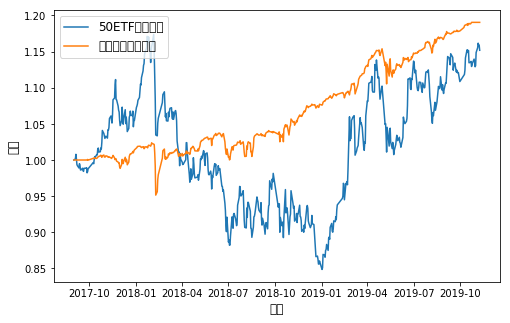

In [99]:
plt.figure(figsize=(8, 5))
plt.plot(etf_price/etf_price.iloc[0], label='50ETF现货净值')
plt.plot(pfl_nv2, label='备兑看涨策略净值')
plt.legend(loc='upper left', fontsize='large')
plt.xlabel('时间',size=12)
plt.ylabel('净值',size=12)
plt.show()